## 1000 yearly universe dict

In [1]:
import pickle

with open("data/eligible_dict.pkl", "rb") as f:
    eligible_dict = pickle.load(f)

## Set backtest year: 2017~2024

In [2]:
universe_years = list(range(2017, 2025))

In [3]:
import pandas as pd 
import numpy as np
df = pd.read_parquet("data/df_featured.parquet")
df_hardtoborrow = pd.read_parquet("data/df_hardtoborrow.parquet")
eligibility_50m = pd.read_parquet("data/eligibility_50m.parquet")
eligibility_250m = pd.read_parquet("data/eligibility_250m.parquet")
eligibility_1b = pd.read_parquet("data/eligibility_1b.parquet")
df

,instrument_id,date,open,high,low,close,volume,adj_factor,adjusted_open,adjusted_high,...,LINEARREG_SLOPE_volume_20,HT_DCPHASE_volume,WILLR_5,CCI_5,ADX_5,NATR_5,WILLR_20,CCI_20,ADX_20,NATR_20
0,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1.939596,41.307375,42.509730,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1.939597,42.645538,43.401787,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1.939596,44.856262,50.325147,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1.939592,41.908382,42.645427,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1.939593,42.335100,43.013763,...,NaN,NaN,-87.659864,-28.032724,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4911311,1611,2022-12-23,16.6700,16.7800,16.4600,16.7700,392000.0,0.784192,13.072481,13.158742,...,17528.496241,211.924788,-33.333333,33.240997,28.047631,2.730248,-70.212766,-77.848711,12.920911,2.895398
4911312,1611,2022-12-27,16.7000,16.7900,16.5300,16.7600,623900.0,0.784195,13.096048,13.166626,...,10548.120301,246.517750,-34.523810,36.585366,26.305573,2.495764,-70.744681,-69.074513,12.891537,2.829835
4911313,1611,2022-12-28,16.8800,17.0500,16.4150,16.4600,1044300.0,0.784192,13.237161,13.370473,...,7624.962406,270.656042,-86.764706,-72.916667,23.739748,2.804569,-86.702128,-80.732511,12.515981,2.930232
4911314,1611,2022-12-29,16.4000,16.4900,16.2000,16.2800,916000.0,0.797518,13.079302,13.151079,...,10732.781955,294.763637,-90.588235,-166.666667,21.319372,2.624728,-95.767196,-136.566997,12.401064,2.903565


## Seperate different kinds of features

In [4]:
# ============================================================
# Feature groups for modelling / ablation
# ============================================================

fundamental_cols = [
    "valuation_score",
    "quality_score",
    "health_score",
    "momentum_score",
    "final_score",
    "final_score_clean",
    "value_trap",
    "piot_norm",
]


earnings_revision_cols = [
    "epsp",
    "epsf",
    "reps1",
    "repsf4",
    "sue",
    "inesp",
    "inesn",
    "reps41",
    "repsfs",
    "repsfl",
    "deps",
]

returns_volatility_liquidity_cols = [
    "return_1",
    "return_5",
    "return_20",
    "overnight_return",
    "ret_std_20",
    "on_ret_std_20",
    "range_pct",
    "estimate_turnover",
    "twr_20",
    "volume_z_20",
    "dist_to_high_20",
    "dist_to_low_20",
    "channel_pos_20",
]


technical_indicator_cols = [
    "DEMA_open_5",
    "KAMA_open_5",
    "MIDPOINT_open_5",
    "LINEARREG_SLOPE_open_5",
    "DEMA_open_20",
    "KAMA_open_20",
    "MIDPOINT_open_20",
    "LINEARREG_SLOPE_open_20",
    "HT_DCPHASE_open",

    "DEMA_high_5",
    "KAMA_high_5",
    "MIDPOINT_high_5",
    "LINEARREG_SLOPE_high_5",
    "DEMA_high_20",
    "KAMA_high_20",
    "MIDPOINT_high_20",
    "LINEARREG_SLOPE_high_20",
    "HT_DCPHASE_high",

    "DEMA_low_5",
    "KAMA_low_5",
    "MIDPOINT_low_5",
    "LINEARREG_SLOPE_low_5",
    "DEMA_low_20",
    "KAMA_low_20",
    "MIDPOINT_low_20",
    "LINEARREG_SLOPE_low_20",
    "HT_DCPHASE_low",

    "DEMA_close_5",
    "KAMA_close_5",
    "MIDPOINT_close_5",
    "LINEARREG_SLOPE_close_5",
    "DEMA_close_20",
    "KAMA_close_20",
    "MIDPOINT_close_20",
    "LINEARREG_SLOPE_close_20",
    "HT_DCPHASE_close",

    "DEMA_volume_5",
    "KAMA_volume_5",
    "MIDPOINT_volume_5",
    "LINEARREG_SLOPE_volume_5",
    "DEMA_volume_20",
    "KAMA_volume_20",
    "MIDPOINT_volume_20",
    "LINEARREG_SLOPE_volume_20",
    "HT_DCPHASE_volume",

    "WILLR_5",
    "CCI_5",
    "ADX_5",
    "NATR_5",
    "WILLR_20",
    "CCI_20",
    "ADX_20",
    "NATR_20",
]



short_interest_cols = [
    "dsi",
    "dtcn",
    "ddtcn",
]

In [5]:
feature_groups = {
    "fundamental": fundamental_cols,
    "earnings_revision": earnings_revision_cols,
    "returns_volatility_liquidity": returns_volatility_liquidity_cols,
    "technical_indicator": technical_indicator_cols,
    "short_interest": short_interest_cols,
}

In [6]:
list(feature_groups.values())

[['valuation_score',
  'quality_score',
  'health_score',
  'momentum_score',
  'final_score',
  'final_score_clean',
  'value_trap',
  'piot_norm'],
 ['epsp',
  'epsf',
  'reps1',
  'repsf4',
  'sue',
  'inesp',
  'inesn',
  'reps41',
  'repsfs',
  'repsfl',
  'deps'],
 ['return_1',
  'return_5',
  'return_20',
  'overnight_return',
  'ret_std_20',
  'on_ret_std_20',
  'range_pct',
  'estimate_turnover',
  'twr_20',
  'volume_z_20',
  'dist_to_high_20',
  'dist_to_low_20',
  'channel_pos_20'],
 ['DEMA_open_5',
  'KAMA_open_5',
  'MIDPOINT_open_5',
  'LINEARREG_SLOPE_open_5',
  'DEMA_open_20',
  'KAMA_open_20',
  'MIDPOINT_open_20',
  'LINEARREG_SLOPE_open_20',
  'HT_DCPHASE_open',
  'DEMA_high_5',
  'KAMA_high_5',
  'MIDPOINT_high_5',
  'LINEARREG_SLOPE_high_5',
  'DEMA_high_20',
  'KAMA_high_20',
  'MIDPOINT_high_20',
  'LINEARREG_SLOPE_high_20',
  'HT_DCPHASE_high',
  'DEMA_low_5',
  'KAMA_low_5',
  'MIDPOINT_low_5',
  'LINEARREG_SLOPE_low_5',
  'DEMA_low_20',
  'KAMA_low_20',
  'MI

In [7]:
base_cols = [
    "instrument_id",
    "date",
    "market_cap",
    "gics_industry",
]

feature_cols = [
    col
    for group_cols in feature_groups.values()
    for col in group_cols
]

target_cols = [
    "target_c2o_next_adj",
]

selected_cols = base_cols + feature_cols + target_cols

# 保險：只留 df 裡真的存在的欄位
selected_cols = [c for c in selected_cols if c in df.columns]

df = df[selected_cols].copy()

df

,instrument_id,date,market_cap,gics_industry,valuation_score,quality_score,health_score,momentum_score,final_score,final_score_clean,...,ADX_5,NATR_5,WILLR_20,CCI_20,ADX_20,NATR_20,dsi,dtcn,ddtcn,target_c2o_next_adj
0,1,2013-12-12,2.116608e+10,253010.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.046608
1,1,2013-12-13,2.175675e+10,253010.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004181
2,1,2013-12-16,2.118577e+10,253010.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000917
3,1,2013-12-17,2.147131e+10,253010.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.003663
4,1,2013-12-18,2.149100e+10,253010.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.009873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4911311,1611,2022-12-23,2.903138e+09,601010.0,-0.045794,0.301289,-1.340432,-0.430755,-1.133956,-1.133956,...,28.047631,2.730248,-70.212766,-77.848711,12.920911,2.895398,0.088148,20.888611,12.413199,0.007157
4911312,1611,2022-12-27,2.901407e+09,601010.0,-0.045794,0.301289,-1.349364,-0.412515,-1.126558,-1.126558,...,26.305573,2.495764,-70.744681,-69.074513,12.891537,2.829835,0.088148,20.888611,12.413199,0.013287
4911313,1611,2022-12-28,2.849472e+09,601010.0,-0.049836,0.290034,-1.339772,-0.394678,-1.120579,-1.120579,...,23.739748,2.804569,-86.702128,-80.732511,12.515981,2.930232,0.088148,20.888611,12.413199,-0.003077
4911314,1611,2022-12-29,2.818311e+09,601010.0,-0.045794,0.301289,-1.349364,-0.412515,-1.129775,-1.129775,...,21.319372,2.624728,-95.767196,-136.566997,12.401064,2.903565,0.088148,20.888611,12.413199,0.014810


In [8]:
df['market_cap'].isna().sum(), df['gics_industry'].isna().sum()

(28372, 0)

<Axes: xlabel='date'>

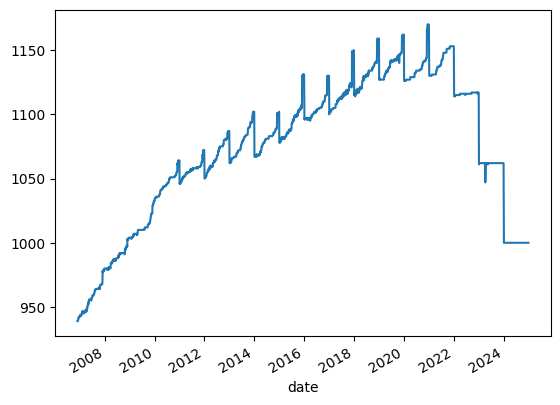

In [9]:
df[df['market_cap'].notna()].groupby('date').size().plot()

## Split to 8 yearly universe data: previous year + universe year

In [10]:
def get_monthly_factor_mining_data(
    df: pd.DataFrame,
    target_year: int,
    target_month: int,
    symbol_col: str = "instrument_id",
    time_col: str = "date",
    pool_dict: dict = None,
    lookback_months: int = 37,
) -> pd.DataFrame:

    if target_month < 1 or target_month > 12:
        raise ValueError("target_month 必須介於 1 到 12")

    if target_year not in pool_dict:
        raise ValueError(f"pool_dict 中找不到 target_year={target_year}")

    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col])
    out = out.sort_values([symbol_col, time_col]).reset_index(drop=True)

    target_month_start = pd.Timestamp(year=target_year, month=target_month, day=1)
    start_month = target_month_start - pd.DateOffset(months=lookback_months)

    out = out[
        (out[time_col] >= start_month) &
        (out[time_col] <= pd.Timestamp(year=target_year, month=12, day=31)) &
        (out[symbol_col].isin(pool_dict[target_year]))
    ].reset_index(drop=True)

    
    return out



In [11]:
all_dfs = []

for y in range(2017, 2025):
    df_tem = get_monthly_factor_mining_data(
        df=df,
        target_year=y,
        target_month=1,
        pool_dict=eligible_dict,
        lookback_months=12
    )
    all_dfs.append(df_tem)


## Fill Market cap with CS median

In [12]:
def fill_market_cap_by_cross_section_median(
    all_dfs: list[pd.DataFrame],
    date_col: str = "date",
    value_col: str = "market_cap",
) -> tuple[list[pd.DataFrame], pd.DataFrame]:
    """
    For each dataframe in all_dfs:
    - identify dates with missing market_cap
    - fill missing market_cap by same-date cross-sectional median
    - return filled dataframes and missing-value report
    """

    filled_dfs = []
    report_rows = []

    for k, df in enumerate(all_dfs):
        out = df.copy()
        out[date_col] = pd.to_datetime(out[date_col])

        # before filling: missing count by date
        daily_missing = (
            out.groupby(date_col)[value_col]
            .agg(
                n_total="size",
                n_missing=lambda x: x.isna().sum(),
                n_available=lambda x: x.notna().sum(),
                cs_median="median",
            )
            .reset_index()
        )

        daily_missing["df_id"] = k
        daily_missing["has_missing"] = daily_missing["n_missing"] > 0

        report_rows.append(daily_missing)

        # same-date cross-sectional median
        cs_median_by_date = out.groupby(date_col)[value_col].transform("median")

        # fill missing market_cap with same-date median
        out[value_col] = out[value_col].fillna(cs_median_by_date)

        # safety check: if an entire date is missing, median is NaN and cannot be filled
        remaining_missing = out[value_col].isna().sum()
        if remaining_missing > 0:
            print(
                f"[Warning] dataframe {k}: still has {remaining_missing} missing "
                f"{value_col}. This means some dates have all values missing."
            )

        filled_dfs.append(out)

    missing_report = pd.concat(report_rows, ignore_index=True)

    return filled_dfs, missing_report

all_dfs, market_cap_missing_report = fill_market_cap_by_cross_section_median(
    all_dfs=all_dfs,
    date_col="date",
    value_col="market_cap",
)

## Feature Confirmation in Yearly Universe 
- For every CS in the previous year, I want the NaN value of a feature < 50%
- If NaN > 50% for any CS in previous year, drop that feature

In [13]:
import pandas as pd
import numpy as np


def filter_features_by_training_year_missingness_fast(
    all_dfs: list[pd.DataFrame],
    universe_years: list[int],
    feature_groups: dict[str, list[str]],
    date_col: str = "date",
    missing_threshold: float = 0.50,
) -> tuple[list[pd.DataFrame], dict[int, list[str]], pd.DataFrame, pd.DataFrame]:

    if len(all_dfs) != len(universe_years):
        raise ValueError("len(all_dfs) must equal len(universe_years).")

    candidate_cols = [
        col
        for group_cols in feature_groups.values()
        for col in group_cols
    ]
    candidate_cols = list(dict.fromkeys(candidate_cols))

    all_dfs_filtered = []
    valid_feature_cols_by_year = {}
    dropped_rows = []
    daily_report_list = []

    for df_raw, universe_year in zip(all_dfs, universe_years):
        df = df_raw.copy()
        df[date_col] = pd.to_datetime(df[date_col])
        train_year = universe_year - 1

        train_mask = df[date_col].dt.year.eq(train_year)
        train_df = df.loc[train_mask].copy()

        if train_df.empty:
            raise ValueError(
                f"Universe year {universe_year}: no training-year data found for {train_year}."
            )

        check_cols = [c for c in candidate_cols if c in df.columns]

        # 一次性計算每日總筆數
        n_total_by_date = train_df.groupby(date_col).size()

        # 一次性計算所有 feature 每日 missing 數
        missing_counts = (
            train_df
            .groupby(date_col)[check_cols]
            .apply(lambda x: x.isna().sum())
        )

        # daily missing fraction: index=date, columns=features
        missing_frac = missing_counts.div(n_total_by_date, axis=0)

        # 每個 feature 的最大 daily missing fraction
        max_missing_frac = missing_frac.max(axis=0)

        # 是否要刪除
        dropped_cols = max_missing_frac[
            max_missing_frac > missing_threshold
        ].index.tolist()

        valid_cols = [
            c for c in check_cols
            if c not in dropped_cols
        ]

        # 建 dropped report
        for col in dropped_cols:
            worst_date = missing_frac[col].idxmax()
            n_total = int(n_total_by_date.loc[worst_date])
            n_missing = int(missing_counts.loc[worst_date, col])

            dropped_rows.append({
                "universe_year": universe_year,
                "train_year": train_year,
                "feature": col,
                "max_missing_frac": float(missing_frac.loc[worst_date, col]),
                "worst_date": worst_date,
                "n_total_on_worst_date": n_total,
                "n_missing_on_worst_date": n_missing,
                "n_available_on_worst_date": n_total - n_missing,
                "reason": f"daily missing fraction > {missing_threshold:.0%} in training year",
            })

        # 建 daily report，長表格式
        daily_report = (
            missing_frac
            .reset_index()
            .melt(
                id_vars=date_col,
                var_name="feature",
                value_name="missing_frac",
            )
        )
        daily_report["universe_year"] = universe_year
        daily_report["train_year"] = train_year

        daily_report_list.append(daily_report)

        # 從整個 previous-year + current-year df 刪掉 bad features
        df_filtered = df.drop(columns=dropped_cols, errors="ignore")

        all_dfs_filtered.append(df_filtered)
        valid_feature_cols_by_year[universe_year] = valid_cols

        print(
            f"Universe year {universe_year}: "
            f"checked {len(check_cols)} features, "
            f"kept {len(valid_cols)}, "
            f"dropped {len(dropped_cols)}."
        )

    dropped_feature_report = pd.DataFrame(dropped_rows)

    daily_missing_report = (
        pd.concat(daily_report_list, ignore_index=True)
        if daily_report_list
        else pd.DataFrame()
    )

    return (
        all_dfs_filtered,
        valid_feature_cols_by_year,
        dropped_feature_report,
        daily_missing_report,
    )

In [14]:
all_dfs_filtered, valid_feature_cols_by_year, dropped_feature_report, daily_missing_report = (
    filter_features_by_training_year_missingness_fast(
        all_dfs=all_dfs,
        universe_years=universe_years,
        feature_groups=feature_groups,
        date_col="date",
        missing_threshold=0.50,
    )
)

Universe year 2017: checked 88 features, kept 88, dropped 0.
Universe year 2018: checked 88 features, kept 88, dropped 0.
Universe year 2019: checked 88 features, kept 88, dropped 0.
Universe year 2020: checked 88 features, kept 88, dropped 0.
Universe year 2021: checked 88 features, kept 88, dropped 0.
Universe year 2022: checked 88 features, kept 88, dropped 0.
Universe year 2023: checked 88 features, kept 88, dropped 0.
Universe year 2024: checked 88 features, kept 88, dropped 0.


# Cut off Extreme Values
Using 5 MAD

In [15]:
import numpy as np
import pandas as pd


def median_mad_winsorize_cross_section_fast(
    df: pd.DataFrame,
    cols: list[str],
    date_col: str = "date",
    n_mad: float = 5.0,
) -> pd.DataFrame:
    """
    Cross-sectional median-MAD winsorization by date.

    For each date t and feature x:
        median_t = median_i(x_{i,t})
        mad_t    = median_i(|x_{i,t} - median_t|)
        lower_t  = median_t - n_mad * mad_t
        upper_t  = median_t + n_mad * mad_t

    Then clip each x_{i,t} into [lower_t, upper_t].

    If mad_t == 0 or NaN, the feature-date is left unchanged.
    """

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    cols = [c for c in cols if c in out.columns]

    if not cols:
        return out

    # Ensure numeric
    out[cols] = out[cols].apply(pd.to_numeric, errors="coerce")

    # Cross-sectional median by date
    cs_median = out.groupby(date_col)[cols].transform("median")

    # Cross-sectional MAD by date
    abs_dev = (out[cols] - cs_median).abs()
    cs_mad = abs_dev.groupby(out[date_col]).transform("median")

    lower = cs_median - n_mad * cs_mad
    upper = cs_median + n_mad * cs_mad

    # If MAD is 0 or NaN, do not clip that feature-date
    valid_mad = cs_mad.notna() & (cs_mad != 0)

    clipped = out[cols].clip(lower=lower, upper=upper, axis=0)

    out[cols] = out[cols].where(~valid_mad, clipped)

    return out

In [16]:
def winsorize_all_dfs_by_year(
    all_dfs: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    date_col: str = "date",
    n_mad: float = 5.0,
) -> list[pd.DataFrame]:
    """
    Apply cross-sectional median-MAD winsorization to each yearly dataframe.

    Each dataframe uses that year's valid feature columns only.
    """

    if len(all_dfs) != len(universe_years):
        raise ValueError("len(all_dfs) must equal len(universe_years).")

    out_dfs = []

    for year, df_year in zip(universe_years, all_dfs):
        cols = valid_feature_cols_by_year[year]
        cols = [c for c in cols if c in df_year.columns]

        df_w = median_mad_winsorize_cross_section_fast(
            df=df_year,
            cols=cols,
            date_col=date_col,
            n_mad=n_mad,
        )

        out_dfs.append(df_w)

        print(
            f"Universe year {year}: winsorized {len(cols)} features "
            f"with {n_mad} MAD threshold."
        )

    return out_dfs

In [17]:
all_dfs_winsor = winsorize_all_dfs_by_year(
    all_dfs=all_dfs,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    date_col="date",
    n_mad=5.0,
)

Universe year 2017: winsorized 88 features with 5.0 MAD threshold.
Universe year 2018: winsorized 88 features with 5.0 MAD threshold.
Universe year 2019: winsorized 88 features with 5.0 MAD threshold.
Universe year 2020: winsorized 88 features with 5.0 MAD threshold.
Universe year 2021: winsorized 88 features with 5.0 MAD threshold.
Universe year 2022: winsorized 88 features with 5.0 MAD threshold.
Universe year 2023: winsorized 88 features with 5.0 MAD threshold.
Universe year 2024: winsorized 88 features with 5.0 MAD threshold.


In [18]:
def summarize_winsorization_changes(
    all_dfs_before: list[pd.DataFrame],
    all_dfs_after: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
) -> pd.DataFrame:
    rows = []

    for year, before, after in zip(universe_years, all_dfs_before, all_dfs_after):
        cols = [c for c in valid_feature_cols_by_year[year] if c in before.columns and c in after.columns]

        for col in cols:
            b = before[col]
            a = after[col]

            changed = b.notna() & a.notna() & (b != a)

            rows.append({
                "universe_year": year,
                "feature": col,
                "n_changed": int(changed.sum()),
                "changed_frac": float(changed.mean()),
            })

    return (
        pd.DataFrame(rows)
        .sort_values(["universe_year", "changed_frac"], ascending=[True, False])
        .reset_index(drop=True)
    )
winsor_change_report = summarize_winsorization_changes(
    all_dfs_before=all_dfs,
    all_dfs_after=all_dfs_winsor,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
)

display(winsor_change_report.head(30))

,universe_year,feature,n_changed,changed_frac
0,2017,LINEARREG_SLOPE_volume_5,80729,0.160495
1,2017,LINEARREG_SLOPE_volume_20,79536,0.158124
2,2017,estimate_turnover,63533,0.126308
3,2017,deps,63384,0.126012
4,2017,MIDPOINT_volume_20,62780,0.124811
5,2017,DEMA_volume_5,62271,0.123799
6,2017,MIDPOINT_volume_5,62160,0.123579
7,2017,DEMA_volume_20,60829,0.120933
8,2017,KAMA_volume_5,60073,0.119430
9,2017,KAMA_volume_20,57705,0.114722


# Impute features by industry CS median

In [19]:
def impute_features_by_industry_median_cross_section_with_report(
    df: pd.DataFrame,
    feature_cols: list[str],
    date_col: str = "date",
    id_col: str = "instrument_id",
    industry_col: str = "gics_industry",
    fallback_value: float = 0.0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Same-date same-industry median imputation with detailed report.

    Imputation hierarchy:
    1. same-date same-industry median
    2. same-date market median
    3. fallback_value
    """

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    if id_col not in out.columns:
        raise ValueError(f"{id_col} not found in df.")
    if industry_col not in out.columns:
        raise ValueError(f"{industry_col} not found in df.")

    feature_cols = [c for c in feature_cols if c in out.columns]

    if not feature_cols:
        raise ValueError("No valid feature columns found.")

    out[feature_cols] = out[feature_cols].apply(pd.to_numeric, errors="coerce")

    original_missing = out[feature_cols].isna()

    # -----------------------------
    # Same-date same-industry median
    # -----------------------------
    industry_median = (
        out.groupby([date_col, industry_col], observed=True)[feature_cols]
        .transform("median")
    )

    industry_available_count = (
        out.groupby([date_col, industry_col], observed=True)[feature_cols]
        .transform("count")
    )

    # -----------------------------
    # Same-date market median fallback
    # -----------------------------
    market_median = (
        out.groupby(date_col)[feature_cols]
        .transform("median")
    )

    market_available_count = (
        out.groupby(date_col)[feature_cols]
        .transform("count")
    )

    # -----------------------------
    # Decide imputation method
    # -----------------------------
    used_industry = original_missing & industry_median.notna()
    used_market = original_missing & industry_median.isna() & market_median.notna()
    used_fallback = original_missing & industry_median.isna() & market_median.isna()

    # -----------------------------
    # Fill values
    # -----------------------------
    out[feature_cols] = (
        out[feature_cols]
        .fillna(industry_median)
        .fillna(market_median)
        .fillna(fallback_value)
    )

    # -----------------------------
    # Build detailed long report
    # -----------------------------
    base_cols = [id_col, date_col, industry_col]

    report_frames = []

    for method_name, method_mask, value_source, n_ind_source, n_market_source in [
        (
            "industry_median",
            used_industry,
            industry_median,
            industry_available_count,
            market_available_count,
        ),
        (
            "market_median",
            used_market,
            market_median,
            industry_available_count,
            market_available_count,
        ),
        (
            "fallback_value",
            used_fallback,
            pd.DataFrame(
                fallback_value,
                index=out.index,
                columns=feature_cols,
            ),
            industry_available_count,
            market_available_count,
        ),
    ]:
        if not method_mask.to_numpy().any():
            continue

        mask_long = (
            method_mask
            .reset_index()
            .melt(
                id_vars="index",
                var_name="feature",
                value_name="was_imputed_by_method",
            )
        )

        mask_long = mask_long.loc[mask_long["was_imputed_by_method"]].copy()

        if mask_long.empty:
            continue

        value_long = (
            value_source
            .reset_index()
            .melt(
                id_vars="index",
                var_name="feature",
                value_name="imputed_value",
            )
        )

        n_ind_long = (
            n_ind_source
            .reset_index()
            .melt(
                id_vars="index",
                var_name="feature",
                value_name="n_available_same_industry",
            )
        )

        n_market_long = (
            n_market_source
            .reset_index()
            .melt(
                id_vars="index",
                var_name="feature",
                value_name="n_available_market",
            )
        )

        meta = out[base_cols].reset_index()

        temp_report = (
            mask_long[["index", "feature"]]
            .merge(meta, on="index", how="left")
            .merge(value_long, on=["index", "feature"], how="left")
            .merge(n_ind_long, on=["index", "feature"], how="left")
            .merge(n_market_long, on=["index", "feature"], how="left")
        )

        temp_report["impute_method"] = method_name

        report_frames.append(temp_report)

    if report_frames:
        impute_report = pd.concat(report_frames, ignore_index=True)
        impute_report = impute_report[
            [
                date_col,
                id_col,
                industry_col,
                "feature",
                "impute_method",
                "imputed_value",
                "n_available_same_industry",
                "n_available_market",
            ]
        ].sort_values([date_col, "feature", id_col])
    else:
        impute_report = pd.DataFrame(
            columns=[
                date_col,
                id_col,
                industry_col,
                "feature",
                "impute_method",
                "imputed_value",
                "n_available_same_industry",
                "n_available_market",
            ]
        )

    return out, impute_report

In [20]:
def impute_all_dfs_by_industry_median_with_report(
    all_dfs: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    date_col: str = "date",
    id_col: str = "instrument_id",
    industry_col: str = "gics_industry",
    fallback_value: float = 0.0,
) -> tuple[list[pd.DataFrame], pd.DataFrame]:
    """
    Apply same-date same-industry median imputation to every yearly dataframe.
    Also return a detailed imputation report.
    """

    if len(all_dfs) != len(universe_years):
        raise ValueError("len(all_dfs) must equal len(universe_years).")

    out_dfs = []
    report_list = []

    for year, df_year in zip(universe_years, all_dfs):
        feature_cols = [
            c for c in valid_feature_cols_by_year[year]
            if c in df_year.columns
        ]

        df_imputed, impute_report_year = (
            impute_features_by_industry_median_cross_section_with_report(
                df=df_year,
                feature_cols=feature_cols,
                date_col=date_col,
                id_col=id_col,
                industry_col=industry_col,
                fallback_value=fallback_value,
            )
        )

        impute_report_year["universe_year"] = year

        n_missing_after = df_imputed[feature_cols].isna().sum().sum()
        n_imputed = len(impute_report_year)

        print(
            f"Universe year {year}: imputed {len(feature_cols)} features. "
            f"Total imputed cells = {n_imputed}. "
            f"Remaining missing = {n_missing_after}."
        )

        out_dfs.append(df_imputed)
        report_list.append(impute_report_year)

    impute_report = (
        pd.concat(report_list, ignore_index=True)
        if report_list
        else pd.DataFrame()
    )

    return out_dfs, impute_report

In [21]:
all_dfs_imputed, impute_report = impute_all_dfs_by_industry_median_with_report(
    all_dfs=all_dfs,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    date_col="date",
    id_col="instrument_id",
    industry_col="gics_industry",
    fallback_value=0.0,
)

Universe year 2017: imputed 88 features. Total imputed cells = 269420. Remaining missing = 0.
Universe year 2018: imputed 88 features. Total imputed cells = 262507. Remaining missing = 0.
Universe year 2019: imputed 88 features. Total imputed cells = 226376. Remaining missing = 0.
Universe year 2020: imputed 88 features. Total imputed cells = 210259. Remaining missing = 0.
Universe year 2021: imputed 88 features. Total imputed cells = 176969. Remaining missing = 0.
Universe year 2022: imputed 88 features. Total imputed cells = 168309. Remaining missing = 0.
Universe year 2023: imputed 88 features. Total imputed cells = 114080. Remaining missing = 0.
Universe year 2024: imputed 88 features. Total imputed cells = 106259. Remaining missing = 0.


In [22]:
impute_summary_by_year = (
    impute_report
    .groupby(["universe_year", "impute_method"])
    .size()
    .rename("n_imputed_cells")
    .reset_index()
)

display(impute_summary_by_year)

,universe_year,impute_method,n_imputed_cells
0,2017,industry_median,269420
1,2018,industry_median,262507
2,2019,industry_median,226376
3,2020,industry_median,210259
4,2021,industry_median,176969
5,2022,industry_median,165808
6,2022,market_median,2501
7,2023,industry_median,113147
8,2023,market_median,933
9,2024,industry_median,106259


In [23]:
impute_summary_by_feature = (
    impute_report
    .groupby(["universe_year", "feature", "impute_method"])
    .size()
    .rename("n_imputed_cells")
    .reset_index()
    .sort_values(["universe_year", "n_imputed_cells"], ascending=[True, False])
)

display(impute_summary_by_feature.head(50))

,universe_year,feature,impute_method,n_imputed_cells
50,2017,repsf4,industry_median,23319
51,2017,repsfl,industry_median,21380
41,2017,inesn,industry_median,20822
42,2017,inesp,industry_median,20822
48,2017,reps1,industry_median,17091
49,2017,reps41,industry_median,15919
37,2017,epsp,industry_median,15883
36,2017,epsf,industry_median,15468
52,2017,repsfs,industry_median,15468
55,2017,sue,industry_median,13967


# Neutralization
- Typically, we expect that Log(Market Cap) and Industry has predictability
- We want to keep a feature's unexplained part, which is the OLS residual
- OLS: Feature = alpha + beta_1 * log(market cap) + beta_industry * industry_dummy_variable + residual
- Since there are no NaNs in Market cap or Industry, we can use the OLS to fill NaN

In [24]:
def neutralize_cross_section_multioutput_ols(
    df: pd.DataFrame,
    feature_cols: list[str],
    continuous_cols: list[str],
    categorical_cols: list[str],
    date_col: str = "date",
    market_cap_col: str = "market_cap",
    add_log_market_cap: bool = True,
    min_obs_buffer: int = 2,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Cross-sectional multi-output OLS neutralization.

    For each date:
        Y = X B + E

    Y contains all feature columns together.
    X contains intercept, continuous controls, and categorical dummies.
    Feature columns are replaced by residuals.
    """

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    if continuous_cols is None:
        continuous_cols = []

    if categorical_cols is None:
        categorical_cols = []

    if add_log_market_cap:
        if market_cap_col not in out.columns:
            raise ValueError(f"{market_cap_col} not found in df.")

        out["log_market_cap"] = np.log(
            pd.to_numeric(out[market_cap_col], errors="coerce")
        )

        if "log_market_cap" not in continuous_cols:
            continuous_cols = ["log_market_cap"] + continuous_cols

    feature_cols = [c for c in feature_cols if c in out.columns]
    continuous_cols = [c for c in continuous_cols if c in out.columns]
    categorical_cols = [c for c in categorical_cols if c in out.columns]

    if not feature_cols:
        raise ValueError("No valid feature columns found.")

    out[feature_cols] = out[feature_cols].apply(pd.to_numeric, errors="coerce")
    out[continuous_cols] = out[continuous_cols].apply(pd.to_numeric, errors="coerce")

    result_parts = []
    beta_records = []

    for dt, g in out.groupby(date_col, sort=True):
        g = g.copy()

        X_parts = [
            pd.DataFrame(
                {"intercept": np.ones(len(g), dtype=float)},
                index=g.index,
            )
        ]

        if continuous_cols:
            X_parts.append(g[continuous_cols].astype(float))

        if categorical_cols:
            cat_parts = []

            for cat_col in categorical_cols:
                dummies = pd.get_dummies(
                    g[cat_col].astype("category"),
                    prefix=cat_col,
                    drop_first=True,
                    dtype=float,
                )
                cat_parts.append(dummies)

            if cat_parts:
                X_parts.append(pd.concat(cat_parts, axis=1))

        X_df = pd.concat(X_parts, axis=1)
        x_names = X_df.columns.tolist()

        valid_x = X_df.notna().all(axis=1)

        X = X_df.loc[valid_x].to_numpy(dtype=float)
        Y = g.loc[valid_x, feature_cols].to_numpy(dtype=float)

        n_obs = X.shape[0]
        n_regressors = X.shape[1]
        min_obs = n_regressors + min_obs_buffer

        if n_obs < min_obs:
            Y_all = g[feature_cols].to_numpy(dtype=float)
            Y_dm = Y_all - np.nanmean(Y_all, axis=0, keepdims=True)
            Y_dm = np.nan_to_num(Y_dm, nan=0.0)

            g.loc[:, feature_cols] = Y_dm

            beta_records.append({
                date_col: pd.Timestamp(dt),
                "feature": "__ALL__",
                "x_col": "FALLBACK",
                "beta": np.nan,
                "n_obs": n_obs,
                "n_total": len(g),
                "note": "insufficient observations; demean fallback",
            })

            result_parts.append(g)
            continue

        try:
            B, *_ = np.linalg.lstsq(X, Y, rcond=None)

            Y_hat = X @ B
            Y_resid = Y - Y_hat

            g.loc[valid_x, feature_cols] = Y_resid

            if (~valid_x).any():
                g.loc[~valid_x, feature_cols] = 0.0

            # beta_df: long format
            for j, x_col in enumerate(x_names):
                for k, feature in enumerate(feature_cols):
                    beta_records.append({
                        date_col: pd.Timestamp(dt),
                        "feature": feature,
                        "x_col": x_col,
                        "beta": float(B[j, k]),
                        "n_obs": n_obs,
                        "n_total": len(g),
                        "note": "",
                    })

        except np.linalg.LinAlgError:
            Y_all = g[feature_cols].to_numpy(dtype=float)
            Y_dm = Y_all - np.nanmean(Y_all, axis=0, keepdims=True)
            Y_dm = np.nan_to_num(Y_dm, nan=0.0)

            g.loc[:, feature_cols] = Y_dm

            beta_records.append({
                date_col: pd.Timestamp(dt),
                "feature": "__ALL__",
                "x_col": "LINALG_ERROR",
                "beta": np.nan,
                "n_obs": n_obs,
                "n_total": len(g),
                "note": "lstsq failed; demean fallback",
            })

        result_parts.append(g)

    out_neu = pd.concat(result_parts, axis=0).sort_index()
    beta_df = pd.DataFrame(beta_records)

    return out_neu, beta_df

In [25]:
def neutralize_all_dfs_multioutput_ols(
    all_dfs_imputed: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    continuous_cols: list[str],
    categorical_cols: list[str],
    date_col: str = "date",
    market_cap_col: str = "market_cap",
    add_log_market_cap: bool = True,
) -> tuple[list[pd.DataFrame], dict[int, pd.DataFrame]]:
    """
    Apply cross-sectional multi-output OLS neutralization to every yearly dataframe.
    """

    if len(all_dfs_imputed) != len(universe_years):
        raise ValueError("len(all_dfs_imputed) must equal len(universe_years).")

    out_dfs = []
    beta_by_year = {}

    for year, df_year in zip(universe_years, all_dfs_imputed):
        feature_cols = [
            c for c in valid_feature_cols_by_year[year]
            if c in df_year.columns
        ]

        df_neu, beta_df = neutralize_cross_section_multioutput_ols(
            df=df_year,
            feature_cols=feature_cols,
            continuous_cols=continuous_cols,
            categorical_cols=categorical_cols,
            date_col=date_col,
            market_cap_col=market_cap_col,
            add_log_market_cap=add_log_market_cap,
        )

        n_missing = df_neu[feature_cols].isna().sum().sum()

        print(
            f"Universe year {year}: neutralized {len(feature_cols)} features. "
            f"Remaining missing = {n_missing}."
        )

        out_dfs.append(df_neu)
        beta_by_year[year] = beta_df

    return out_dfs, beta_by_year

In [26]:
all_dfs_neu, beta_by_year = neutralize_all_dfs_multioutput_ols(
    all_dfs_imputed=all_dfs_imputed,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    continuous_cols=["log_market_cap"],
    categorical_cols=["gics_industry"],
    date_col="date",
    market_cap_col="market_cap",
    add_log_market_cap=True,
)

Universe year 2017: neutralized 88 features. Remaining missing = 0.
Universe year 2018: neutralized 88 features. Remaining missing = 0.
Universe year 2019: neutralized 88 features. Remaining missing = 0.
Universe year 2020: neutralized 88 features. Remaining missing = 0.
Universe year 2021: neutralized 88 features. Remaining missing = 0.
Universe year 2022: neutralized 88 features. Remaining missing = 0.
Universe year 2023: neutralized 88 features. Remaining missing = 0.
Universe year 2024: neutralized 88 features. Remaining missing = 0.


In [27]:
# from pathlib import Path
# import json
# import pandas as pd

# save_dir = Path("processed/all_dfs_neu")
# save_dir.mkdir(parents=True, exist_ok=True)

# universe_years = list(range(2017, 2025))

# # 逐年存 parquet
# for year, df_year in zip(universe_years, all_dfs_neu):
#     path = save_dir / f"universe_{year}_neutralized.parquet"
#     df_year.to_parquet(path, index=False)
#     print(f"Saved {year}: {path}, shape={df_year.shape}")

# # 存 metadata：年份順序
# metadata = {
#     "universe_years": universe_years,
#     "description": "Neutralized and imputed yearly universe dataframes",
# }

# with open(save_dir / "metadata.json", "w") as f:
#     json.dump(metadata, f, indent=4)

In [28]:
# from pathlib import Path
# import json
# import pandas as pd

# save_dir = Path("processed/all_dfs_neu")

# with open(save_dir / "metadata.json", "r") as f:
#     metadata = json.load(f)

# universe_years = metadata["universe_years"]

# all_dfs_neu = []

# for year in universe_years:
#     path = save_dir / f"universe_{year}_neutralized.parquet"
#     df_year = pd.read_parquet(path)
#     df_year["date"] = pd.to_datetime(df_year["date"])
#     all_dfs_neu.append(df_year)

#     print(f"Loaded {year}: shape={df_year.shape}")

# Standarization

In [29]:
def zscore_standardize_cross_section_fast(
    df: pd.DataFrame,
    cols: list[str],
    date_col: str = "date",
    ddof: int = 0,
    fill_zero_if_constant: bool = True,
) -> pd.DataFrame:
    """
    Cross-sectional z-score standardization by date.

    For each date t and feature k:
        z_{i,t,k} = (x_{i,t,k} - mean_{t,k}) / std_{t,k}

    If std is 0 or NaN:
        - fill_zero_if_constant=True: set z-score to 0
        - otherwise: set z-score to NaN

    This function is vectorized across columns.
    """

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    cols = [c for c in cols if c in out.columns]

    if not cols:
        return out

    out[cols] = out[cols].apply(pd.to_numeric, errors="coerce")

    cs_mean = out.groupby(date_col)[cols].transform("mean")
    cs_std = out.groupby(date_col)[cols].transform(lambda x: x.std(ddof=ddof))

    z = (out[cols] - cs_mean) / cs_std

    invalid_std = cs_std.isna() | (cs_std == 0)

    if fill_zero_if_constant:
        z = z.mask(invalid_std, 0.0)
    else:
        z = z.mask(invalid_std, np.nan)

    out[cols] = z

    return out

In [30]:
def zscore_all_dfs_by_year(
    all_dfs_neu: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    date_col: str = "date",
    ddof: int = 0,
    fill_zero_if_constant: bool = True,
) -> list[pd.DataFrame]:
    """
    Apply cross-sectional z-score standardization to every yearly universe dataframe.

    Each year's dataframe uses only that year's valid features.
    """

    if len(all_dfs_neu) != len(universe_years):
        raise ValueError("len(all_dfs_neu) must equal len(universe_years).")

    out_dfs = []

    for year, df_year in zip(universe_years, all_dfs_neu):
        feature_cols = [
            c for c in valid_feature_cols_by_year[year]
            if c in df_year.columns
        ]

        df_z = zscore_standardize_cross_section_fast(
            df=df_year,
            cols=feature_cols,
            date_col=date_col,
            ddof=ddof,
            fill_zero_if_constant=fill_zero_if_constant,
        )

        out_dfs.append(df_z)

        n_missing = df_z[feature_cols].isna().sum().sum()

        print(
            f"Universe year {year}: standardized {len(feature_cols)} features. "
            f"Remaining missing = {n_missing}."
        )

    return out_dfs

In [31]:
all_dfs_z = zscore_all_dfs_by_year(
    all_dfs_neu=all_dfs_neu,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    date_col="date",
    ddof=0,
    fill_zero_if_constant=True,
)

Universe year 2017: standardized 88 features. Remaining missing = 0.
Universe year 2018: standardized 88 features. Remaining missing = 0.
Universe year 2019: standardized 88 features. Remaining missing = 0.
Universe year 2020: standardized 88 features. Remaining missing = 0.
Universe year 2021: standardized 88 features. Remaining missing = 0.
Universe year 2022: standardized 88 features. Remaining missing = 0.
Universe year 2023: standardized 88 features. Remaining missing = 0.
Universe year 2024: standardized 88 features. Remaining missing = 0.


In [32]:
def check_zscore_by_year(
    all_dfs_z: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    date_col: str = "date",
) -> pd.DataFrame:
    rows = []

    for year, df_year in zip(universe_years, all_dfs_z):
        df = df_year.copy()
        df[date_col] = pd.to_datetime(df[date_col])

        cols = [c for c in valid_feature_cols_by_year[year] if c in df.columns]

        daily_mean = df.groupby(date_col)[cols].mean()
        daily_std = df.groupby(date_col)[cols].std(ddof=0)

        rows.append({
            "universe_year": year,
            "max_abs_daily_mean": daily_mean.abs().max().max(),
            "median_daily_std": daily_std.median().median(),
            "min_daily_std": daily_std.min().min(),
            "max_daily_std": daily_std.max().max(),
            "n_missing": df[cols].isna().sum().sum(),
        })

    return pd.DataFrame(rows)


zscore_check = check_zscore_by_year(
    all_dfs_z=all_dfs_z,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    date_col="date",
)

display(zscore_check)

,universe_year,max_abs_daily_mean,median_daily_std,min_daily_std,max_daily_std,n_missing
0,2017,4.624079e-17,1.0,1.0,1.0,0
1,2018,4.388634e-17,1.0,1.0,1.0,0
2,2019,4.529710e-17,1.0,1.0,1.0,0
3,2020,5.023759e-17,1.0,1.0,1.0,0
4,2021,4.751755e-17,1.0,1.0,1.0,0
5,2022,4.463097e-17,1.0,1.0,1.0,0
6,2023,4.263256e-17,1.0,1.0,1.0,0
7,2024,4.751755e-17,1.0,1.0,1.0,0


# Model Part

In [33]:
import numpy as np
import pandas as pd

from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.base import clone
from sklearn.linear_model import ElasticNet

## IC

In [34]:
def daily_spearman_ic_fast(
    df: pd.DataFrame,
    score_col: str,
    target_col: str = "target_c2o_next_adj",
    date_col: str = "date",
    min_names: int = 30,
) -> pd.Series:
    """
    Vectorized daily cross-sectional Spearman IC.

    Spearman IC = Pearson correlation between cross-sectional ranks.
    """

    temp = df[[date_col, score_col, target_col]].copy()
    temp[date_col] = pd.to_datetime(temp[date_col])
    temp[score_col] = pd.to_numeric(temp[score_col], errors="coerce")
    temp[target_col] = pd.to_numeric(temp[target_col], errors="coerce")

    temp = temp.dropna(subset=[score_col, target_col]).copy()

    if temp.empty:
        return pd.Series(dtype=float)

    temp["_score_rank"] = temp.groupby(date_col)[score_col].rank(method="average")
    temp["_target_rank"] = temp.groupby(date_col)[target_col].rank(method="average")

    temp["_score_dm"] = (
        temp["_score_rank"]
        - temp.groupby(date_col)["_score_rank"].transform("mean")
    )

    temp["_target_dm"] = (
        temp["_target_rank"]
        - temp.groupby(date_col)["_target_rank"].transform("mean")
    )

    temp["_cross"] = temp["_score_dm"] * temp["_target_dm"]
    temp["_score_sq"] = temp["_score_dm"] ** 2
    temp["_target_sq"] = temp["_target_dm"] ** 2

    agg = (
        temp.groupby(date_col)
        .agg(
            n_names=(score_col, "size"),
            cov_num=("_cross", "sum"),
            score_var=("_score_sq", "sum"),
            target_var=("_target_sq", "sum"),
        )
    )

    denom = np.sqrt(agg["score_var"] * agg["target_var"])

    ic = agg["cov_num"] / denom
    ic = ic.where(agg["n_names"] >= min_names)
    ic = ic.where(denom > 0)

    return ic.dropna()


def summarize_ic(ic: pd.Series) -> dict:
    if ic.empty:
        return {
            "ic_mean": np.nan,
            "ic_std": np.nan,
            "ic_tstat": np.nan,
            "n_days": 0,
        }

    ic_mean = ic.mean()
    ic_std = ic.std(ddof=1)
    n_days = len(ic)

    if pd.isna(ic_std) or ic_std == 0:
        ic_tstat = np.nan
    else:
        ic_tstat = ic_mean / ic_std * np.sqrt(n_days)

    return {
        "ic_mean": ic_mean,
        "ic_std": ic_std,
        "ic_tstat": ic_tstat,
        "n_days": n_days,
    }

## Linear Regression

In [35]:
def make_cs_winsorized_zscore_target(
    df: pd.DataFrame,
    target_col: str = "target_c2o_next_adj",
    date_col: str = "date",
    n_mad: float = 5.0,
    out_col: str = "target_cs_z",
) -> pd.DataFrame:
    """
    For each date:
    1. Cross-sectional median-MAD winsorize target.
    2. Cross-sectional z-score target.

    The processed target is only used for model training.
    Raw target_col should still be used for IC / PnL evaluation.
    """

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    y = pd.to_numeric(out[target_col], errors="coerce")

    cs_median = y.groupby(out[date_col]).transform("median")

    abs_dev = (y - cs_median).abs()
    cs_mad = abs_dev.groupby(out[date_col]).transform("median")

    lower = cs_median - n_mad * cs_mad
    upper = cs_median + n_mad * cs_mad

    valid_mad = cs_mad.notna() & (cs_mad != 0)

    y_win = y.copy()
    y_win = y_win.where(~valid_mad, y.clip(lower=lower, upper=upper))

    cs_mean = y_win.groupby(out[date_col]).transform("mean")
    cs_std = y_win.groupby(out[date_col]).transform(lambda x: x.std(ddof=0))

    y_z = (y_win - cs_mean) / cs_std
    y_z = y_z.replace([np.inf, -np.inf], np.nan)
    y_z = y_z.where(cs_std.notna() & (cs_std != 0), np.nan)

    out[out_col] = y_z

    return out

In [36]:
def make_elastic_net(params: dict) -> ElasticNet:
    return ElasticNet(
        alpha=params.get("alpha", 1e-4),
        l1_ratio=params.get("l1_ratio", 0.15),
        fit_intercept=True,
        max_iter=params.get("max_iter", 5000),
        tol=params.get("tol", 1e-4),
        random_state=params.get("random_state", 42),
        selection=params.get("selection", "cyclic"),
    )

In [37]:
def fit_select_refit_predict_elastic_net_one_window(
    df_window: pd.DataFrame,
    df_predict: pd.DataFrame,
    feature_cols: list[str],
    param_grid: dict,
    target_col_raw: str = "target_c2o_next_adj",
    target_col_train: str = "target_cs_z",
    date_col: str = "date",
    id_col: str = "instrument_id",
    eligibility_col = "is_eligible",
    n_mad_target: float = 5.0,
    min_train_obs: int = 500,
    min_val_obs: int = 200,
    min_ic_names: int = 30,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    For one prediction month:
    1. Use previous 12 months as train+validation window.
    2. Drop the last date in the 12-month window.
    3. Split first 10 months as train and last 2 months as validation.
    4. Tune Elastic Net hyperparameters by validation mean Spearman IC.
    5. Refit best Elastic Net on the full 12-month window.
    6. Predict all rows in the next prediction month.

    Returns:
    - pred_out: prediction scores for the next month
    - diagnostics: validation results for all parameter combinations
    - coef_df: final model coefficients after refit
    """

    df_window = df_window.copy()
    df_predict = df_predict.copy()

    df_window[date_col] = pd.to_datetime(df_window[date_col])
    df_predict[date_col] = pd.to_datetime(df_predict[date_col])

    # --------------------------------------------------------
    # Use eligible rows consistently, if eligibility_col exists
    # --------------------------------------------------------
    if eligibility_col is not None and eligibility_col in df_window.columns:
        df_window = df_window.loc[df_window[eligibility_col].astype(bool)].copy()

    if eligibility_col is not None and eligibility_col in df_predict.columns:
        df_predict = df_predict.loc[df_predict[eligibility_col].astype(bool)].copy()

    if df_window.empty or df_predict.empty:
        empty_pred = df_predict[[id_col, date_col]].copy()
        empty_pred["score"] = np.nan
        empty_pred["model_name"] = "elastic_net"

        diagnostics = pd.DataFrame([{
            "model_name": "elastic_net",
            "status": "empty_window_or_prediction",
            "best_params": None,
        }])

        coef_df = pd.DataFrame()

        return empty_pred, diagnostics, coef_df

    # --------------------------------------------------------
    # Critical: drop the last date in the 12-month window
    # because target is not known at training time.
    # --------------------------------------------------------
    last_window_date = df_window[date_col].max()
    df_window = df_window.loc[df_window[date_col] < last_window_date].copy()

    if df_window.empty:
        empty_pred = df_predict[[id_col, date_col]].copy()
        empty_pred["score"] = np.nan
        empty_pred["model_name"] = "elastic_net"

        diagnostics = pd.DataFrame([{
            "model_name": "elastic_net",
            "status": "empty_after_dropping_last_date",
            "best_params": None,
        }])

        coef_df = pd.DataFrame()

        return empty_pred, diagnostics, coef_df

    # --------------------------------------------------------
    # Build training target inside this window only
    # --------------------------------------------------------
    df_window = make_cs_winsorized_zscore_target(
        df=df_window,
        target_col=target_col_raw,
        date_col=date_col,
        n_mad=n_mad_target,
        out_col=target_col_train,
    )

    df_window = df_window.dropna(subset=[target_col_raw, target_col_train]).copy()

    feature_cols = [
        c for c in feature_cols
        if c in df_window.columns and c in df_predict.columns
    ]

    if not feature_cols:
        empty_pred = df_predict[[id_col, date_col]].copy()
        empty_pred["score"] = np.nan
        empty_pred["model_name"] = "elastic_net"

        diagnostics = pd.DataFrame([{
            "model_name": "elastic_net",
            "status": "no_valid_features",
            "best_params": None,
        }])

        coef_df = pd.DataFrame()

        return empty_pred, diagnostics, coef_df

    # --------------------------------------------------------
    # Split first 10 months train, last 2 months validation
    # --------------------------------------------------------
    window_start = df_window[date_col].min().normalize()
    val_start = window_start + pd.DateOffset(months=10)

    train_df = df_window.loc[df_window[date_col] < val_start].copy()
    val_df = df_window.loc[df_window[date_col] >= val_start].copy()

    train_df = train_df.dropna(subset=feature_cols + [target_col_train])
    val_df = val_df.dropna(subset=feature_cols + [target_col_raw, target_col_train])

    if len(train_df) < min_train_obs or len(val_df) < min_val_obs:
        empty_pred = df_predict[[id_col, date_col]].copy()
        empty_pred["score"] = np.nan
        empty_pred["model_name"] = "elastic_net"

        diagnostics = pd.DataFrame([{
            "model_name": "elastic_net",
            "status": "skipped_insufficient_data",
            "n_train": len(train_df),
            "n_val": len(val_df),
            "best_params": None,
            "val_ic_mean": np.nan,
            "val_ic_tstat": np.nan,
            "val_n_days": 0,
        }])

        coef_df = pd.DataFrame()

        return empty_pred, diagnostics, coef_df

    X_train = train_df[feature_cols].to_numpy(dtype=float)
    y_train = train_df[target_col_train].to_numpy(dtype=float)

    X_val = val_df[feature_cols].to_numpy(dtype=float)

    best_score = -np.inf
    best_params = None

    diag_rows = []

    # --------------------------------------------------------
    # Hyperparameter search
    # --------------------------------------------------------
    for params in ParameterGrid(param_grid):
        model = make_elastic_net(params)

        try:
            model.fit(X_train, y_train)
            val_score = model.predict(X_val)
        except Exception as e:
            diag_rows.append({
                "model_name": "elastic_net",
                "status": "fit_failed",
                "params": params,
                "error": str(e),
                "val_ic_mean": np.nan,
                "val_ic_tstat": np.nan,
                "val_n_days": 0,
                "n_train": len(train_df),
                "n_val": len(val_df),
            })
            continue

        val_eval = val_df[[id_col, date_col, target_col_raw]].copy()
        val_eval["score"] = val_score

        ic = daily_spearman_ic_fast(
            df=val_eval,
            score_col="score",
            target_col=target_col_raw,
            date_col=date_col,
            min_names=min_ic_names,
        )

        ic_summary = summarize_ic(ic)

        row = {
            "model_name": "elastic_net",
            "status": "ok",
            "params": params,
            "val_ic_mean": ic_summary["ic_mean"],
            "val_ic_std": ic_summary["ic_std"],
            "val_ic_tstat": ic_summary["ic_tstat"],
            "val_n_days": ic_summary["n_days"],
            "n_train": len(train_df),
            "n_val": len(val_df),
            "n_features": len(feature_cols),
            "n_nonzero_coef": int(np.sum(np.abs(model.coef_) > 1e-10)),
        }

        diag_rows.append(row)

        score = ic_summary["ic_mean"]

        if pd.notna(score) and score > best_score:
            best_score = score
            best_params = params

    diagnostics = pd.DataFrame(diag_rows)

    if best_params is None:
        empty_pred = df_predict[[id_col, date_col]].copy()
        empty_pred["score"] = np.nan
        empty_pred["model_name"] = "elastic_net"

        return empty_pred, diagnostics, pd.DataFrame()

    diagnostics["is_best"] = diagnostics["params"].astype(str).eq(str(best_params))

    # --------------------------------------------------------
    # Refit best model on full 12-month window
    # --------------------------------------------------------
    full_train_df = df_window.dropna(subset=feature_cols + [target_col_train]).copy()

    X_full = full_train_df[feature_cols].to_numpy(dtype=float)
    y_full = full_train_df[target_col_train].to_numpy(dtype=float)

    final_model = make_elastic_net(best_params)
    final_model.fit(X_full, y_full)

    # --------------------------------------------------------
    # Predict next month
    # --------------------------------------------------------
    pred_df = df_predict.dropna(subset=feature_cols).copy()
    X_pred = pred_df[feature_cols].to_numpy(dtype=float)

    pred_out = pred_df[[id_col, date_col]].copy()

    if target_col_raw in pred_df.columns:
        pred_out[target_col_raw] = pred_df[target_col_raw].values

    pred_out["model_name"] = "elastic_net"
    pred_out["score"] = final_model.predict(X_pred)
    pred_out["best_params"] = str(best_params)
    pred_out["train_window_start"] = df_window[date_col].min()
    pred_out["train_window_end_exclusive"] = last_window_date
    pred_out["prediction_month"] = pred_out[date_col].dt.to_period("M").astype(str)

    # --------------------------------------------------------
    # Final coefficients
    # --------------------------------------------------------
    coef_df = pd.DataFrame({
        "feature": feature_cols,
        "coef": final_model.coef_,
    })

    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df["is_selected"] = coef_df["abs_coef"] > 1e-10
    coef_df["best_params"] = str(best_params)
    coef_df["train_window_start"] = df_window[date_col].min()
    coef_df["train_window_end_exclusive"] = last_window_date
    coef_df["prediction_month"] = pred_out["prediction_month"].iloc[0] if len(pred_out) else None

    coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

    diagnostics["best_params"] = str(best_params)
    diagnostics["train_window_start"] = df_window[date_col].min()
    diagnostics["train_window_end_exclusive"] = last_window_date
    diagnostics["prediction_month"] = pred_out["prediction_month"].iloc[0] if len(pred_out) else None

    return pred_out, diagnostics, coef_df

In [38]:
def run_elastic_net_monthly_walk_forward_one_universe(
    df_year: pd.DataFrame,
    universe_year: int,
    feature_cols: list[str],
    param_grid: dict,
    target_col_raw: str = "target_c2o_next_adj",
    date_col: str = "date",
    id_col: str = "instrument_id",
    eligibility_col = "is_eligible",
    n_mad_target: float = 5.0,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    For one universe year Y:
    - df_year contains Y-1 and Y.
    - For each month in Y:
        previous 12 months = train + validation
        first 10 months = train
        last 2 months = validation
        select best ElasticNet params
        refit on full 12 months
        predict current month
    """

    df = df_year.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values([date_col, id_col]).reset_index(drop=True)

    prediction_months = pd.period_range(
        start=f"{universe_year}-01",
        end=f"{universe_year}-12",
        freq="M",
    )

    all_predictions = []
    all_diagnostics = []
    all_coefs = []

    for pred_month in prediction_months:
        pred_start = pred_month.to_timestamp()
        pred_end = (pred_month + 1).to_timestamp()

        trainval_start = pred_start - pd.DateOffset(months=12)
        trainval_end = pred_start

        df_window = df.loc[
            (df[date_col] >= trainval_start)
            & (df[date_col] < trainval_end)
        ].copy()

        df_predict = df.loc[
            (df[date_col] >= pred_start)
            & (df[date_col] < pred_end)
        ].copy()

        if df_window.empty or df_predict.empty:
            continue

        pred_out, diag, coef_df = fit_select_refit_predict_elastic_net_one_window(
            df_window=df_window,
            df_predict=df_predict,
            feature_cols=feature_cols,
            param_grid=param_grid,
            target_col_raw=target_col_raw,
            target_col_train="target_cs_z",
            date_col=date_col,
            id_col=id_col,
            eligibility_col=eligibility_col,
            n_mad_target=n_mad_target,
        )

        pred_out["universe_year"] = universe_year
        diag["universe_year"] = universe_year
        coef_df["universe_year"] = universe_year

        all_predictions.append(pred_out)
        all_diagnostics.append(diag)
        all_coefs.append(coef_df)

        print(
            f"Universe {universe_year}, predict {pred_month}: done. "
            f"Trainval = {trainval_start.date()} to {trainval_end.date()}."
        )

    predictions = (
        pd.concat(all_predictions, ignore_index=True)
        if all_predictions
        else pd.DataFrame()
    )

    diagnostics = (
        pd.concat(all_diagnostics, ignore_index=True)
        if all_diagnostics
        else pd.DataFrame()
    )

    coef_table = (
        pd.concat(all_coefs, ignore_index=True)
        if all_coefs
        else pd.DataFrame()
    )

    return predictions, diagnostics, coef_table

In [39]:
def run_elastic_net_monthly_walk_forward_all_universes(
    all_dfs_z: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    param_grid: dict,
    target_col_raw: str = "target_c2o_next_adj",
    date_col: str = "date",
    id_col: str = "instrument_id",
    eligibility_col = "is_eligible",
    n_mad_target: float = 5.0,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    if len(all_dfs_z) != len(universe_years):
        raise ValueError("len(all_dfs_z) must equal len(universe_years).")

    all_predictions = []
    all_diagnostics = []
    all_coefs = []

    for df_year, year in zip(all_dfs_z, universe_years):
        feature_cols = [
            c for c in valid_feature_cols_by_year[year]
            if c in df_year.columns
        ]

        pred, diag, coef_df = run_elastic_net_monthly_walk_forward_one_universe(
            df_year=df_year,
            universe_year=year,
            feature_cols=feature_cols,
            param_grid=param_grid,
            target_col_raw=target_col_raw,
            date_col=date_col,
            id_col=id_col,
            eligibility_col=eligibility_col,
            n_mad_target=n_mad_target,
        )

        all_predictions.append(pred)
        all_diagnostics.append(diag)
        all_coefs.append(coef_df)

    predictions = pd.concat(all_predictions, ignore_index=True)
    diagnostics = pd.concat(all_diagnostics, ignore_index=True)
    coef_table = pd.concat(all_coefs, ignore_index=True)

    return predictions, diagnostics, coef_table

In [81]:
elastic_net_param_grid = {
    "alpha": [0.01, 0.05, 0.1],
    "l1_ratio": [0.25, 0.30, 0.35],
    "max_iter": [5000],
    "tol": [1e-4],
    "random_state": [2026],
    "selection": ["cyclic"],
}

In [45]:
predictions_enet, diagnostics_enet, coef_table_enet = (
    run_elastic_net_monthly_walk_forward_all_universes(
        all_dfs_z=all_dfs_z,
        universe_years=universe_years,
        valid_feature_cols_by_year=valid_feature_cols_by_year,
        param_grid=elastic_net_param_grid,
        target_col_raw="target_c2o_next_adj",
        date_col="date",
        id_col="instrument_id",
        eligibility_col="is_eligible",
        n_mad_target=5.0,
    )
)

Universe 2017, predict 2017-01: done. Trainval = 2016-01-01 to 2017-01-01.
Universe 2017, predict 2017-02: done. Trainval = 2016-02-01 to 2017-02-01.
Universe 2017, predict 2017-03: done. Trainval = 2016-03-01 to 2017-03-01.
Universe 2017, predict 2017-04: done. Trainval = 2016-04-01 to 2017-04-01.
Universe 2017, predict 2017-05: done. Trainval = 2016-05-01 to 2017-05-01.
Universe 2017, predict 2017-06: done. Trainval = 2016-06-01 to 2017-06-01.
Universe 2017, predict 2017-07: done. Trainval = 2016-07-01 to 2017-07-01.
Universe 2017, predict 2017-08: done. Trainval = 2016-08-01 to 2017-08-01.
Universe 2017, predict 2017-09: done. Trainval = 2016-09-01 to 2017-09-01.
Universe 2017, predict 2017-10: done. Trainval = 2016-10-01 to 2017-10-01.
Universe 2017, predict 2017-11: done. Trainval = 2016-11-01 to 2017-11-01.
Universe 2017, predict 2017-12: done. Trainval = 2016-12-01 to 2017-12-01.
Universe 2018, predict 2018-01: done. Trainval = 2017-01-01 to 2018-01-01.
Universe 2018, predict 20

In [46]:
# -----------------------------
# Best parameter table
# -----------------------------
if "is_best" not in diagnostics_enet.columns:
    diagnostics_enet["is_best"] = False

diagnostics_enet["is_best"] = (
    diagnostics_enet["is_best"]
    .fillna(False)
    .astype(bool)
)

best_param_table = (
    diagnostics_enet
    .loc[diagnostics_enet["is_best"]]
    .sort_values(["universe_year", "prediction_month"])
    .reset_index(drop=True)
)

display(best_param_table)


# -----------------------------
# Selected feature count
# -----------------------------
if not coef_table_enet.empty and "is_selected" in coef_table_enet.columns:
    coef_table_enet["is_selected"] = (
        coef_table_enet["is_selected"]
        .fillna(False)
        .astype(bool)
    )

    selected_feature_count = (
        coef_table_enet
        .groupby(["universe_year", "prediction_month"])["is_selected"]
        .sum()
        .rename("n_selected_features")
        .reset_index()
    )

    display(selected_feature_count)
else:
    print("coef_table_enet is empty or missing 'is_selected'.")


# -----------------------------
# Feature selection frequency
# -----------------------------
if not coef_table_enet.empty and "is_selected" in coef_table_enet.columns:
    feature_selection_frequency = (
        coef_table_enet
        .groupby("feature")["is_selected"]
        .mean()
        .rename("selection_frequency")
        .reset_index()
        .sort_values("selection_frequency", ascending=False)
    )

    display(feature_selection_frequency.head(30))
else:
    print("No coefficient table available.")


# -----------------------------
# Predictions
# -----------------------------
display(predictions_enet.head())

,model_name,status,params,val_ic_mean,val_ic_std,val_ic_tstat,val_n_days,n_train,n_val,n_features,n_nonzero_coef,is_best,best_params,train_window_start,train_window_end_exclusive,prediction_month,universe_year
0,elastic_net,ok,"{'alpha': 0.01, 'l1_ratio': 0.35, 'max_iter': ...",0.037005,0.052323,4.359683,38,212999,38000,88,17,True,"{'alpha': 0.01, 'l1_ratio': 0.35, 'max_iter': ...",2016-01-04,2016-12-30,2017-01,2017
1,elastic_net,ok,"{'alpha': 0.01, 'l1_ratio': 0.25, 'max_iter': ...",0.026225,0.054589,3.038333,40,211999,40000,88,23,True,"{'alpha': 0.01, 'l1_ratio': 0.25, 'max_iter': ...",2016-02-01,2017-01-31,2017-02,2017
2,elastic_net,ok,"{'alpha': 0.05, 'l1_ratio': 0.25, 'max_iter': ...",0.026658,0.062958,2.610173,38,212999,38000,88,6,True,"{'alpha': 0.05, 'l1_ratio': 0.25, 'max_iter': ...",2016-03-01,2017-02-28,2017-03,2017
3,elastic_net,ok,"{'alpha': 0.01, 'l1_ratio': 0.35, 'max_iter': ...",0.017778,0.065357,1.741712,41,211000,41000,88,17,True,"{'alpha': 0.01, 'l1_ratio': 0.35, 'max_iter': ...",2016-04-01,2017-03-31,2017-04,2017
4,elastic_net,ok,"{'alpha': 0.01, 'l1_ratio': 0.25, 'max_iter': ...",0.013001,0.073286,1.121953,40,210000,40000,88,24,True,"{'alpha': 0.01, 'l1_ratio': 0.25, 'max_iter': ...",2016-05-02,2017-04-28,2017-05,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,elastic_net,ok,"{'alpha': 0.01, 'l1_ratio': 0.25, 'max_iter': ...",0.011803,0.070529,1.058399,40,211000,40000,88,22,True,"{'alpha': 0.01, 'l1_ratio': 0.25, 'max_iter': ...",2023-08-01,2024-07-31,2024-08,2024
92,elastic_net,ok,"{'alpha': 0.05, 'l1_ratio': 0.3, 'max_iter': 5...",0.010080,0.045751,1.444764,43,207000,43000,88,1,True,"{'alpha': 0.05, 'l1_ratio': 0.3, 'max_iter': 5...",2023-09-01,2024-08-30,2024-09,2024
93,elastic_net,ok,"{'alpha': 0.01, 'l1_ratio': 0.25, 'max_iter': ...",0.015567,0.057925,1.699674,40,210000,40000,88,20,True,"{'alpha': 0.01, 'l1_ratio': 0.25, 'max_iter': ...",2023-10-02,2024-09-30,2024-10,2024
94,elastic_net,ok,"{'alpha': 0.01, 'l1_ratio': 0.3, 'max_iter': 5...",0.017002,0.060839,1.811115,42,209000,42000,88,21,True,"{'alpha': 0.01, 'l1_ratio': 0.3, 'max_iter': 5...",2023-11-01,2024-10-31,2024-11,2024


,universe_year,prediction_month,n_selected_features
0,2017,2017-01,18
1,2017,2017-02,21
2,2017,2017-03,6
3,2017,2017-04,17
4,2017,2017-05,21
...,...,...,...
91,2024,2024-08,24
92,2024,2024-09,0
93,2024,2024-10,24
94,2024,2024-11,19


,feature,selection_frequency
49,NATR_20,0.645833
70,overnight_return,0.614583
62,estimate_turnover,0.541667
83,sue,0.500000
66,inesn,0.500000
80,return_1,0.468750
73,range_pct,0.468750
77,repsfl,0.458333
0,ADX_20,0.447917
82,return_5,0.437500


,instrument_id,date,target_c2o_next_adj,model_name,score,best_params,train_window_start,train_window_end_exclusive,prediction_month,universe_year
0,1,2017-01-03,0.001035,elastic_net,0.415287,"{'alpha': 0.01, 'l1_ratio': 0.35, 'max_iter': ...",2016-01-04,2016-12-30,2017-01,2017
1,2,2017-01-03,0.001716,elastic_net,-0.008385,"{'alpha': 0.01, 'l1_ratio': 0.35, 'max_iter': ...",2016-01-04,2016-12-30,2017-01,2017
2,3,2017-01-03,-0.000271,elastic_net,-0.009732,"{'alpha': 0.01, 'l1_ratio': 0.35, 'max_iter': ...",2016-01-04,2016-12-30,2017-01,2017
3,4,2017-01-03,-0.023305,elastic_net,0.045864,"{'alpha': 0.01, 'l1_ratio': 0.35, 'max_iter': ...",2016-01-04,2016-12-30,2017-01,2017
4,5,2017-01-03,-0.001539,elastic_net,0.049211,"{'alpha': 0.01, 'l1_ratio': 0.35, 'max_iter': ...",2016-01-04,2016-12-30,2017-01,2017


In [48]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

best_param_table = diagnostics_enet.copy()

# 確保 is_best 是 bool
best_param_table["is_best"] = (
    best_param_table["is_best"]
    .fillna(False)
    .astype(bool)
)

best_param_table = (
    best_param_table
    .loc[best_param_table["is_best"]]
    .copy()
)

# best_params 若是 string，就轉回 dict
def parse_params(x):
    if isinstance(x, dict):
        return x
    if pd.isna(x):
        return {}
    return ast.literal_eval(x)

best_param_table["best_params_dict"] = best_param_table["best_params"].apply(parse_params)

best_param_table["alpha"] = best_param_table["best_params_dict"].apply(lambda d: d.get("alpha"))
best_param_table["l1_ratio"] = best_param_table["best_params_dict"].apply(lambda d: d.get("l1_ratio"))

display(
    best_param_table[
        ["universe_year", "prediction_month", "val_ic_mean", "val_ic_tstat", "alpha", "l1_ratio"]
    ]
)

,universe_year,prediction_month,val_ic_mean,val_ic_tstat,alpha,l1_ratio
2,2017,2017-01,0.037005,4.359683,0.01,0.35
9,2017,2017-02,0.026225,3.038333,0.01,0.25
21,2017,2017-03,0.026658,2.610173,0.05,0.25
29,2017,2017-04,0.017778,1.741712,0.01,0.35
36,2017,2017-05,0.013001,1.121953,0.01,0.25
...,...,...,...,...,...,...
819,2024,2024-08,0.011803,1.058399,0.01,0.25
832,2024,2024-09,0.010080,1.444764,0.05,0.30
837,2024,2024-10,0.015567,1.699674,0.01,0.25
847,2024,2024-11,0.017002,1.811115,0.01,0.30


,alpha,count,fraction
0,0.01,66,0.687500
1,0.05,23,0.239583
2,0.10,7,0.072917


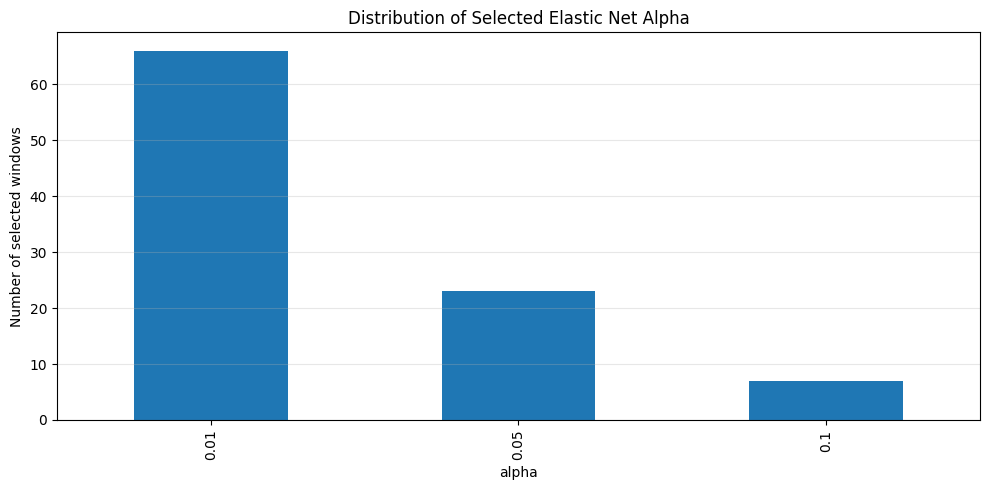

In [49]:
alpha_dist = (
    best_param_table
    .groupby("alpha")
    .size()
    .rename("count")
    .reset_index()
    .sort_values("alpha")
)

alpha_dist["fraction"] = alpha_dist["count"] / alpha_dist["count"].sum()

display(alpha_dist)
fig, ax = plt.subplots(figsize=(10, 5))

alpha_dist.plot(
    x="alpha",
    y="count",
    kind="bar",
    ax=ax,
    legend=False,
)

ax.set_title("Distribution of Selected Elastic Net Alpha")
ax.set_xlabel("alpha")
ax.set_ylabel("Number of selected windows")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

,l1_ratio,count,fraction
0,0.25,58,0.604167
1,0.30,16,0.166667
2,0.35,22,0.229167


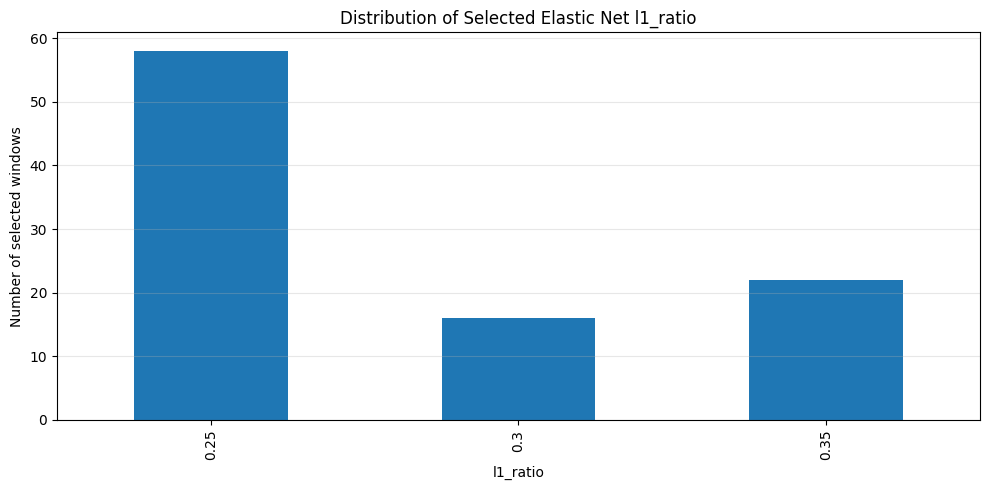

In [51]:
l1_ratio_dist = (
    best_param_table
    .groupby("l1_ratio")
    .size()
    .rename("count")
    .reset_index()
    .sort_values("l1_ratio")
)

l1_ratio_dist["fraction"] = l1_ratio_dist["count"] / l1_ratio_dist["count"].sum()

display(l1_ratio_dist)
fig, ax = plt.subplots(figsize=(10, 5))

l1_ratio_dist.plot(
    x="l1_ratio",
    y="count",
    kind="bar",
    ax=ax,
    legend=False,
)

ax.set_title("Distribution of Selected Elastic Net l1_ratio")
ax.set_xlabel("l1_ratio")
ax.set_ylabel("Number of selected windows")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

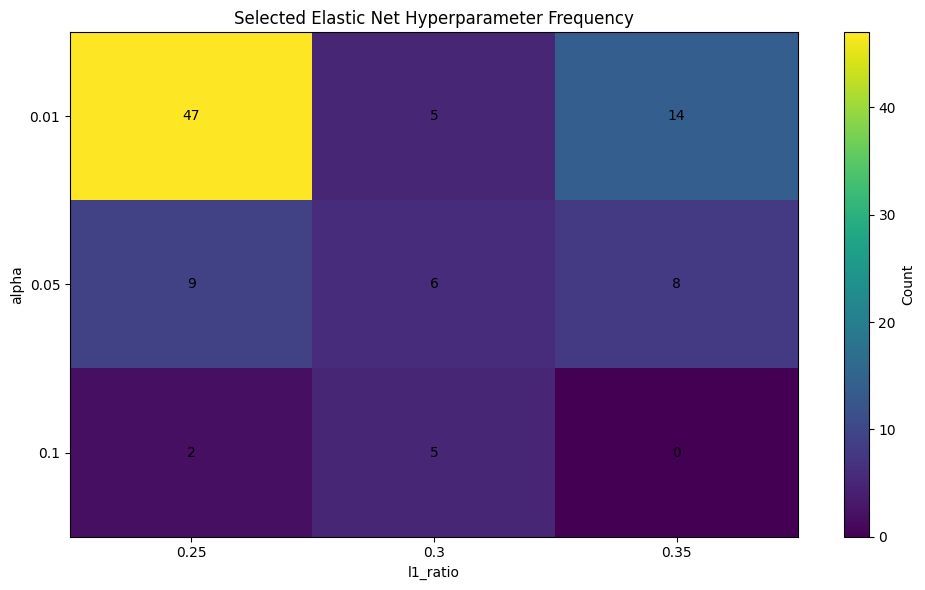

In [52]:
heatmap_data = (
    best_param_table
    .pivot_table(
        index="alpha",
        columns="l1_ratio",
        values="prediction_month",
        aggfunc="count",
        fill_value=0,
    )
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(heatmap_data.values, aspect="auto")

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("l1_ratio")
ax.set_ylabel("alpha")
ax.set_title("Selected Elastic Net Hyperparameter Frequency")

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(
            j,
            i,
            int(heatmap_data.iloc[i, j]),
            ha="center",
            va="center",
        )

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

In [54]:
predictions_enet#[["date", "instrument_id", "model_name", "score"]].head()

,instrument_id,date,target_c2o_next_adj,model_name,score,best_params,train_window_start,train_window_end_exclusive,prediction_month,universe_year
0,1,2017-01-03,0.001035,elastic_net,0.415287,"{'alpha': 0.01, 'l1_ratio': 0.35, 'max_iter': ...",2016-01-04,2016-12-30,2017-01,2017
1,2,2017-01-03,0.001716,elastic_net,-0.008385,"{'alpha': 0.01, 'l1_ratio': 0.35, 'max_iter': ...",2016-01-04,2016-12-30,2017-01,2017
2,3,2017-01-03,-0.000271,elastic_net,-0.009732,"{'alpha': 0.01, 'l1_ratio': 0.35, 'max_iter': ...",2016-01-04,2016-12-30,2017-01,2017
3,4,2017-01-03,-0.023305,elastic_net,0.045864,"{'alpha': 0.01, 'l1_ratio': 0.35, 'max_iter': ...",2016-01-04,2016-12-30,2017-01,2017
4,5,2017-01-03,-0.001539,elastic_net,0.049211,"{'alpha': 0.01, 'l1_ratio': 0.35, 'max_iter': ...",2016-01-04,2016-12-30,2017-01,2017
...,...,...,...,...,...,...,...,...,...,...
2009973,1591,2024-12-27,0.008373,elastic_net,-0.000190,"{'alpha': 0.05, 'l1_ratio': 0.25, 'max_iter': ...",2023-12-01,2024-11-29,2024-12,2024
2009974,1594,2024-12-27,0.001452,elastic_net,0.000385,"{'alpha': 0.05, 'l1_ratio': 0.25, 'max_iter': ...",2023-12-01,2024-11-29,2024-12,2024
2009975,1599,2024-12-27,0.011494,elastic_net,0.001687,"{'alpha': 0.05, 'l1_ratio': 0.25, 'max_iter': ...",2023-12-01,2024-11-29,2024-12,2024
2009976,1604,2024-12-27,0.009410,elastic_net,-0.000004,"{'alpha': 0.05, 'l1_ratio': 0.25, 'max_iter': ...",2023-12-01,2024-11-29,2024-12,2024


In [61]:
predictions_enet.columns

Index(['instrument_id', 'date', 'target_c2o_next_adj', 'model_name', 'score',
       'best_params', 'train_window_start', 'train_window_end_exclusive',
       'prediction_month', 'universe_year'],
      dtype='object')

In [65]:
predict_cols = [
    'instrument_id', 'date', 'target_c2o_next_adj', 'score',
       ]

eligibility_cols = [
    'instrument_id', 'date', 'slippage_commission_bps', 'is_eligible',
]

signal_50m = predictions_enet[predict_cols].merge(
    eligibility_50m[eligibility_cols],
    how="left",
    on=["instrument_id", "date"],
    suffixes=("", "_elig"),
    validate="m:1",
)

borrow_cols = [
    "instrument_id",
    "date",
    "borrow_rate_daily",
]

signal_50m = signal_50m.merge(
    df_hardtoborrow[borrow_cols],
    how="left",
    on=["instrument_id", "date"],
    validate="m:1",
)

signal_50m

,instrument_id,date,target_c2o_next_adj,score,slippage_commission_bps,is_eligible,borrow_rate_daily
0,1,2017-01-03,0.001035,0.415287,5.760282,True,0.000016
1,2,2017-01-03,0.001716,-0.008385,3.731812,True,0.000016
2,3,2017-01-03,-0.000271,-0.009732,4.188951,True,0.000016
3,4,2017-01-03,-0.023305,0.045864,4.309480,True,0.000079
4,5,2017-01-03,-0.001539,0.049211,9.730895,True,0.000016
...,...,...,...,...,...,...,...
2009973,1591,2024-12-27,0.008373,-0.000190,8.705233,True,0.000016
2009974,1594,2024-12-27,0.001452,0.000385,7.240005,False,0.000016
2009975,1599,2024-12-27,0.011494,0.001687,8.296321,True,0.000016
2009976,1604,2024-12-27,0.009410,-0.000004,6.924581,True,0.000016


In [80]:
signal_50m[signal_50m['is_eligible'] == True]['is_eligible'].max()/10000

0.0001

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def build_long_short_daily_returns(
    signal_df: pd.DataFrame,
    n_long: int = 100,
    n_short: int = 100,
    date_col: str = "date",
    id_col: str = "instrument_id",
    score_col: str = "score",
    return_col: str = "target_c2o_next_adj",
    eligible_col: str = "is_eligible",
    cost_bps_col: str = "slippage_commission_bps",
    borrow_rate_daily_col: str = "borrow_rate_daily",
    long_capital_weight: float = 0.5,
    short_capital_weight: float = 0.5,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build daily long-short portfolio return.

    Long:
        top n_long eligible stocks by score.

    Short:
        bottom n_short eligible stocks by score.

    Net long stock return:
        raw_return - trading_cost

    Net short stock return:
        -raw_return - trading_cost - borrow_cost

    trading_cost:
        slippage_commission_bps / 10000

    borrow_cost:
        borrow_rate_daily, only charged on short names.

    Returns
    -------
    daily_return_df:
        Daily portfolio return and diagnostics.

    position_df:
        Stock-level selected positions.
    """

    df = signal_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    required_cols = [
        date_col,
        id_col,
        score_col,
        return_col,
        eligible_col,
        cost_bps_col,
        borrow_rate_daily_col,
    ]

    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
    df[return_col] = pd.to_numeric(df[return_col], errors="coerce")
    df[cost_bps_col] = pd.to_numeric(df[cost_bps_col], errors="coerce")
    df[borrow_rate_daily_col] = pd.to_numeric(df[borrow_rate_daily_col], errors="coerce")

    df = df.loc[df[eligible_col].eq(True)].copy()

    df = df.dropna(
        subset=[
            date_col,
            id_col,
            score_col,
            return_col,
            cost_bps_col,
            borrow_rate_daily_col,
        ]
    ).copy()

    # -----------------------------
    # Daily ranking among eligible stocks
    # -----------------------------
    df["rank_desc"] = (
        df.groupby(date_col)[score_col]
        .rank(method="first", ascending=False)
    )

    df["rank_asc"] = (
        df.groupby(date_col)[score_col]
        .rank(method="first", ascending=True)
    )

    df["side"] = 0

    df.loc[df["rank_desc"] <= n_long, "side"] = 1
    df.loc[df["rank_asc"] <= n_short, "side"] = -1

    position_df = df.loc[df["side"].ne(0)].copy()

    # -----------------------------
    # Costs
    # -----------------------------
    position_df["trading_cost"] = position_df[cost_bps_col] / 10000.0

    position_df["borrow_cost"] = np.where(
        position_df["side"].eq(-1),
        position_df[borrow_rate_daily_col],
        0.0,
    )

    # Long return = raw return - cost
    # Short return = -raw return - cost - borrow
    position_df["stock_net_return"] = np.where(
        position_df["side"].eq(1),
        position_df[return_col] - position_df["trading_cost"],
        -position_df[return_col] - position_df["trading_cost"] - position_df["borrow_cost"],
    )

    position_df["stock_gross_return"] = np.where(
        position_df["side"].eq(1),
        position_df[return_col],
        -position_df[return_col],
    )

    # -----------------------------
    # Daily long / short book return
    # -----------------------------
    long_daily = (
        position_df.loc[position_df["side"].eq(1)]
        .groupby(date_col)
        .agg(
            long_return_net=("stock_net_return", "mean"),
            long_return_gross=("stock_gross_return", "mean"),
            n_long_actual=(id_col, "count"),
            long_avg_trading_cost=("trading_cost", "mean"),
        )
    )

    short_daily = (
        position_df.loc[position_df["side"].eq(-1)]
        .groupby(date_col)
        .agg(
            short_return_net=("stock_net_return", "mean"),
            short_return_gross=("stock_gross_return", "mean"),
            n_short_actual=(id_col, "count"),
            short_avg_trading_cost=("trading_cost", "mean"),
            short_avg_borrow_cost=("borrow_cost", "mean"),
        )
    )

    daily_return_df = (
        long_daily
        .join(short_daily, how="outer")
        .sort_index()
        .reset_index()
    )

    daily_return_df["portfolio_return_gross"] = (
        long_capital_weight * daily_return_df["long_return_gross"]
        + short_capital_weight * daily_return_df["short_return_gross"]
    )

    daily_return_df["portfolio_return_net"] = (
        long_capital_weight * daily_return_df["long_return_net"]
        + short_capital_weight * daily_return_df["short_return_net"]
    )

    daily_return_df["cum_return_gross"] = (
        1.0 + daily_return_df["portfolio_return_gross"].fillna(0.0)
    ).cumprod() - 1.0

    daily_return_df["cum_return_net"] = (
        1.0 + daily_return_df["portfolio_return_net"].fillna(0.0)
    ).cumprod() - 1.0

    return daily_return_df, position_df

In [67]:
daily_ret_50m, position_50m = build_long_short_daily_returns(
    signal_df=signal_50m,
    n_long=100,
    n_short=100,
    date_col="date",
    id_col="instrument_id",
    score_col="score",
    return_col="target_c2o_next_adj",
    eligible_col="is_eligible",
    cost_bps_col="slippage_commission_bps",
    borrow_rate_daily_col="borrow_rate_daily",
)

In [68]:
def compute_performance_metrics(
    daily_return_df: pd.DataFrame,
    return_col: str = "portfolio_return_net",
    date_col: str = "date",
    periods_per_year: int = 252,
) -> pd.Series:
    df = daily_return_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

    r = pd.to_numeric(df[return_col], errors="coerce").dropna()

    if r.empty:
        return pd.Series(dtype=float)

    equity = (1.0 + r).cumprod()

    total_return = equity.iloc[-1] - 1.0

    n_days = len(r)
    ann_return = equity.iloc[-1] ** (periods_per_year / n_days) - 1.0

    ann_vol = r.std(ddof=1) * np.sqrt(periods_per_year)

    sharpe = np.nan
    if ann_vol != 0 and pd.notna(ann_vol):
        sharpe = ann_return / ann_vol

    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    max_drawdown = drawdown.min()

    calmar = np.nan
    if max_drawdown != 0 and pd.notna(max_drawdown):
        calmar = ann_return / abs(max_drawdown)

    win_rate = (r > 0).mean()

    avg_daily_return = r.mean()
    daily_vol = r.std(ddof=1)

    return pd.Series({
        "n_days": n_days,
        "total_return": total_return,
        "annualized_return": ann_return,
        "annualized_volatility": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "calmar": calmar,
        "win_rate": win_rate,
        "avg_daily_return": avg_daily_return,
        "daily_volatility": daily_vol,
        "best_day": r.max(),
        "worst_day": r.min(),
    })

In [72]:
metrics_50m_net = compute_performance_metrics(
    daily_return_df=daily_ret_50m,
    return_col="portfolio_return_net",
    date_col="date",
    periods_per_year=252,
)
metrics_50m_gross = compute_performance_metrics(
    daily_return_df=daily_ret_50m,
    return_col="portfolio_return_gross",
    date_col="date",
    periods_per_year=252,
)

performance_table_50m = pd.concat(
    [
        metrics_50m_gross.rename("gross"),
        metrics_50m_net.rename("net"),
    ],
    axis=1,
)

display(performance_table_50m)

,gross,net
n_days,1949.000000,1949.000000
total_return,0.307735,-0.793973
annualized_return,0.035299,-0.184747
annualized_volatility,0.027445,0.027693
sharpe,1.286171,-6.671292
max_drawdown,-0.035370,-0.793891
calmar,0.997971,-0.232711
win_rate,0.557209,0.242689
avg_daily_return,0.000139,-0.000809
daily_volatility,0.001729,0.001744


In [74]:
def plot_pnl(
    daily_return_df: pd.DataFrame,
    date_col: str = "date",
    save_path = None,
):
    df = daily_return_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

    fig, ax = plt.subplots(figsize=(16, 7))

    ax.plot(
        df[date_col],
        df["cum_return_gross"],
        linewidth=2.0,
        label="Gross cumulative return",
    )

    ax.plot(
        df[date_col],
        df["cum_return_net"],
        linewidth=2.0,
        label="Net cumulative return",
    )

    ax.set_title("Long-Short Strategy Cumulative Return", fontsize=16, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative return")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

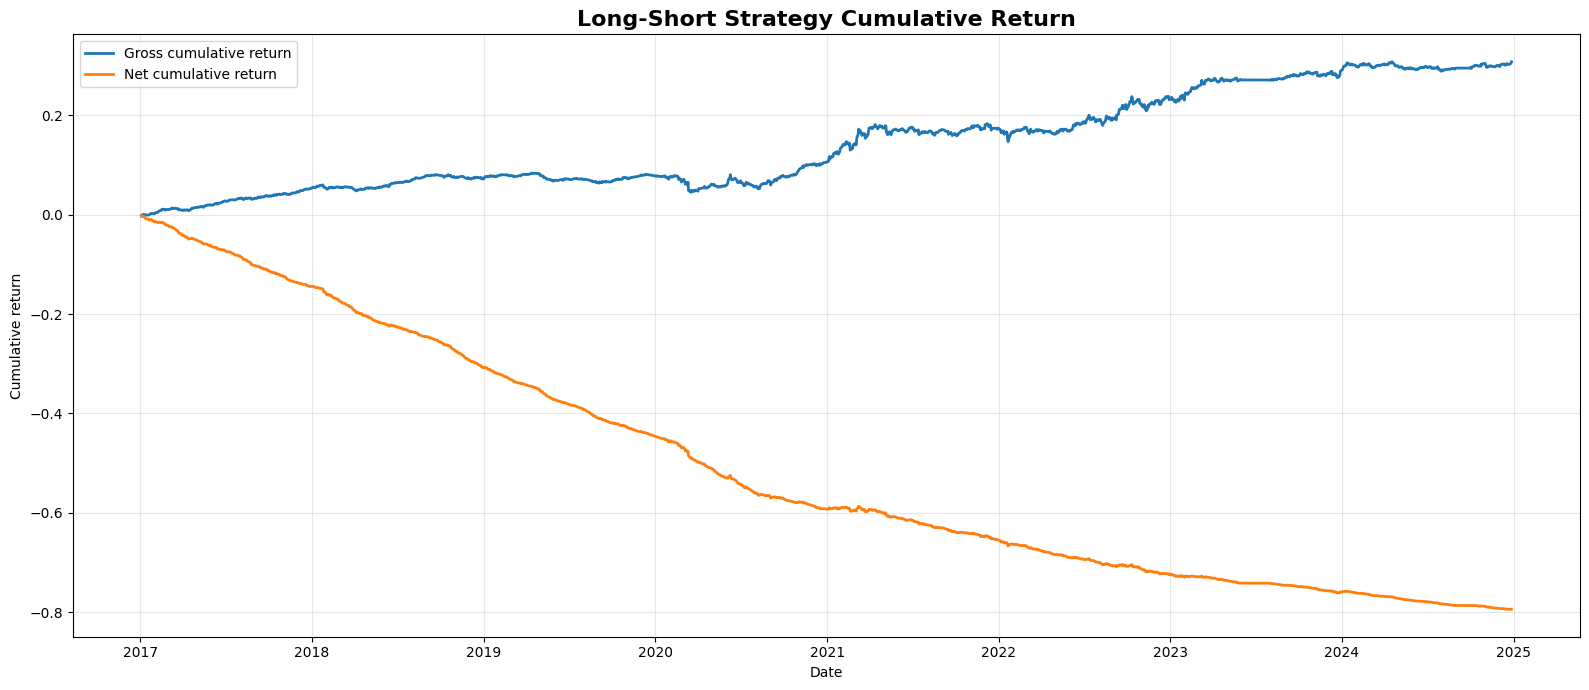

In [75]:
plot_pnl(
    daily_return_df=daily_ret_50m,
    date_col="date",
    save_path="figures/elastic_net_50m_pnl.png",
)